In [2]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [3]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist



In [4]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate



In [5]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/nlsy97-extract.csv.gz")

In [6]:
missing_codes = [-1, -2, -3, -4, -5]
nlsy = pd.read_csv("nlsy97-extract.csv.gz").replace(missing_codes, np.nan)
nlsy.shape

(8984, 34)

In [7]:
nlsy["sat_verbal"] = nlsy["R9793800"]
nlsy["sat_math"] = nlsy["R9793900"]

In [8]:
columns = ["sat_verbal", "sat_math"]
for column in columns:
    invalid = nlsy[column] < 200
    nlsy.loc[invalid, column] = np.nan

In [11]:
nlsy["sat_verbal"]

0       350.0
1       460.0
2         NaN
3         NaN
4         NaN
        ...  
8979      NaN
8980      NaN
8981      NaN
8982      NaN
8983      NaN
Name: sat_verbal, Length: 8984, dtype: float64

In [12]:
nlsy_valid = nlsy.dropna(subset=columns).copy()
nlsy_valid.shape

(1398, 36)

In [13]:
nlsy_valid.head()

,R0000100,R0490200,R0536300,R0536401,R0536402,R1235800,R1318200,R1482600,R3961900,R3989200,...,R9872400,S1552700,U0008900,U1845500,U3444000,U4949700,Z9083800,Z9083900,sat_verbal,sat_math
0,1,NaN,2,9,1981,1,NaN,4,NaN,NaN,...,333.0,NaN,120000.0,NaN,NaN,NaN,16.0,4.0,350.0,470.0
1,2,NaN,1,7,1982,1,145.0,2,NaN,NaN,...,143.0,NaN,98928.0,116000.0,188857.0,180000.0,14.0,2.0,460.0,440.0
7,8,NaN,2,6,1981,1,NaN,4,NaN,NaN,...,240.0,NaN,115000.0,NaN,100000.0,90000.0,18.0,5.0,620.0,620.0
8,9,NaN,1,10,1982,1,NaN,4,NaN,NaN,...,233.0,NaN,157000.0,159000.0,150000.0,130514.0,19.0,5.0,380.0,460.0
9,10,NaN,1,3,1984,1,93.0,4,103.0,110.0,...,320.0,NaN,NaN,175000.0,263000.0,599728.0,16.0,4.0,600.0,560.0


In [16]:
sat_verbal = nlsy_valid["sat_verbal"]
sat_verbal.mean(), sat_verbal.std()

(np.float64(501.80972818311875), np.float64(108.36562024213643))

In [17]:
sat_math = nlsy_valid["sat_math"]
sat_math.mean(), sat_math.std()

(np.float64(503.0829756795422), np.float64(109.8329973731453))

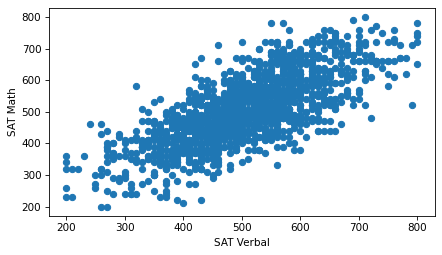

In [19]:
plt.scatter(sat_verbal, sat_math)
decorate(xlabel="SAT Verbal", ylabel="SAT Math")

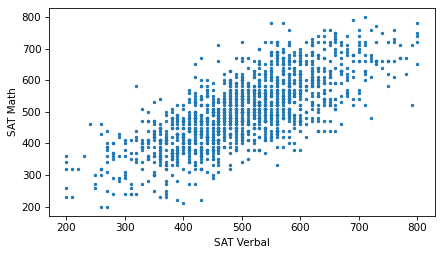

In [21]:
plt.scatter(sat_verbal, sat_math, s=5)
decorate(xlabel="SAT Verbal", ylabel="SAT Math")

In [23]:
def jitter(seq, std=1):
    n = len(seq)
    return np.random.normal(0, std, n) + seq

In [24]:
sat_verbal_jittered = jitter(sat_verbal, 3)
sat_math_jittered = jitter(sat_math, 3)

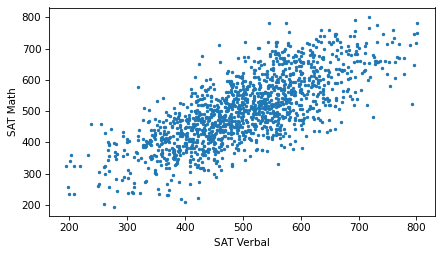

In [25]:
plt.scatter(sat_verbal_jittered, sat_math_jittered, s=5)
decorate(xlabel="SAT Verbal", ylabel="SAT Math")

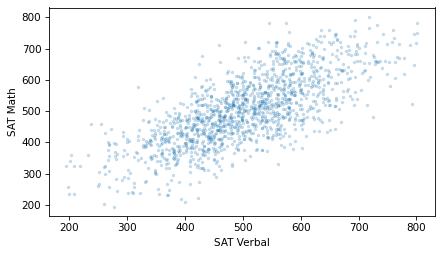

In [27]:
plt.scatter(sat_verbal_jittered, sat_math_jittered, s=5, alpha=0.2)
decorate(xlabel="SAT Verbal", ylabel="SAT Math")


In [28]:
deciles = pd.qcut(nlsy_valid["sat_verbal"], 10, labels=False) + 1
deciles.value_counts().sort_index()

sat_verbal
1     142
2     150
3     139
4     140
5     159
6     130
7     148
8     121
9     138
10    131
Name: count, dtype: int64

In [29]:
deciles

0       1
1       4
7       9
8       2
9       9
       ..
8935    1
8964    3
8969    7
8972    2
8973    3
Name: sat_verbal, Length: 1398, dtype: int64

In [30]:
nlsy_valid["sat_verbal"]

0       350.0
1       460.0
7       620.0
8       380.0
9       600.0
        ...  
8935    300.0
8964    420.0
8969    540.0
8972    370.0
8973    440.0
Name: sat_verbal, Length: 1398, dtype: float64

In [31]:
df_groupby = nlsy_valid.groupby(deciles)
df_groupby

In [35]:
df_groupby.mean()

,R0000100,R0490200,R0536300,R0536401,R0536402,R1235800,R1318200,R1482600,R3961900,R3989200,...,R9872400,S1552700,U0008900,U1845500,U3444000,U4949700,Z9083800,Z9083900,sat_verbal,sat_math
sat_verbal,,,,,,,,,,,,,,,,,,,,,
1,4426.281690,526.538462,1.478873,6.394366,1981.802817,0.704225,90.024096,2.338028,90.833333,92.653846,...,252.753521,89.125000,83904.085714,75618.650000,94636.590476,95304.721154,14.908451,2.873239,315.140845,369.014085
2,4596.860000,519.671875,1.560000,6.773333,1981.880000,0.660000,94.539326,2.653333,96.551724,94.259259,...,272.026667,107.600000,79950.317757,96036.715686,109764.107527,114757.930693,15.234899,3.013333,391.733333,408.400000
3,4071.086331,685.207547,1.597122,6.273381,1981.956835,0.798561,97.764706,2.942446,103.821429,99.833333,...,275.884892,106.500000,96649.000000,112900.352381,129787.651163,148199.673077,16.573529,3.525180,429.784173,451.294964
4,3940.021429,763.333333,1.578571,6.871429,1981.892857,0.828571,100.227848,3.100000,102.482759,96.400000,...,281.185714,110.666667,97528.442308,107277.380952,135587.845361,147881.365385,15.971429,3.521429,459.285714,461.285714
5,3635.496855,718.447761,1.566038,6.572327,1982.006289,0.855346,103.858586,3.194969,104.629630,104.096774,...,308.207547,110.500000,114647.726496,110199.752294,131480.831683,172371.914286,16.125786,3.679245,490.062893,505.471698
6,3535.407692,768.920000,1.523077,5.907692,1981.753846,0.892308,105.788732,3.453846,102.533333,99.000000,...,297.000000,113.333333,114182.430108,148434.806818,158741.277108,197479.139785,16.600000,3.869231,521.692308,520.000000
7,3335.202703,883.381579,1.500000,6.243243,1981.831081,0.925676,105.413333,3.540541,107.692308,107.923077,...,310.547297,113.833333,117116.400000,125828.700000,141162.240000,157867.716981,16.709459,3.979730,550.743243,539.797297
8,3078.595041,542.861538,1.520661,6.247934,1981.983471,0.933884,109.328571,3.570248,113.636364,108.090909,...,327.157025,122.000000,118972.172414,144990.604651,162618.757143,184075.168539,16.851240,4.082645,578.595041,569.090909
9,3378.782609,595.445946,1.492754,6.224638,1981.949275,0.942029,109.512195,3.666667,110.666667,111.074074,...,327.021739,109.750000,126309.040000,144548.445652,144166.300000,176106.861702,17.478261,4.231884,617.681159,588.840580


In [40]:
series_groupby = df_groupby["sat_math"]
series_groupby.mean()

sat_verbal
1     369.014085
2     408.400000
3     451.294964
4     461.285714
5     505.471698
6     520.000000
7     539.797297
8     569.090909
9     588.840580
10    643.969466
Name: sat_math, dtype: float64

In [38]:
low = series_groupby.quantile(0.1)
median = series_groupby.quantile(0.5)
high = series_groupby.quantile(0.9)

In [39]:
low

sat_verbal
1     261.0
2     330.0
3     358.0
4     380.0
5     420.0
6     429.0
7     440.0
8     480.0
9     470.0
10    530.0
Name: sat_math, dtype: float64

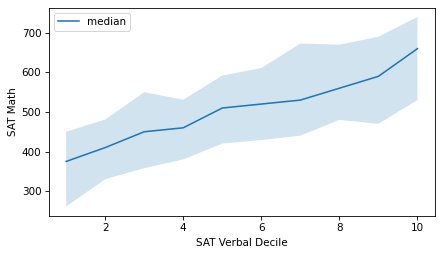

In [42]:
xs = median.index
plt.fill_between(xs, low, high, alpha=0.2)
plt.plot(xs, median, label="median")
decorate(xlabel="SAT Verbal Decile", ylabel="SAT Math")

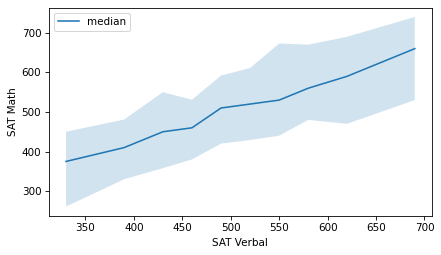

In [43]:
xs = df_groupby["sat_verbal"].median()
plt.fill_between(xs, low, high, alpha=0.2)
plt.plot(xs, median, color="C0", label="median")
decorate(xlabel="SAT Verbal", ylabel="SAT Math")

In [44]:
nlsy["piat_math"] = nlsy["R1318200"]
nlsy["piat_math"].describe()

count    6044.000000
mean       93.903706
std        14.631148
min        55.000000
25%        84.000000
50%        92.000000
75%       103.000000
max       145.000000
Name: piat_math, dtype: float64

In [45]:
nlsy["piat_math"] = nlsy["R1318200"]
nlsy["piat_math"].describe()

count    6044.000000
mean       93.903706
std        14.631148
min        55.000000
25%        84.000000
50%        92.000000
75%       103.000000
max       145.000000
Name: piat_math, dtype: float64

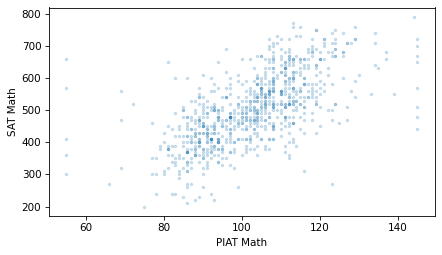

In [46]:
from thinkstats import scatter
scatter(nlsy, "piat_math", "sat_math")
decorate(xlabel="PIAT Math", ylabel="SAT Math")

In [48]:
def standardize(xs):
    return (xs - np.mean(xs)) / np.std(xs)

In [49]:
valid = nlsy.dropna(subset=["piat_math", "sat_math"])
piat_math = valid["piat_math"]
sat_math = valid["sat_math"]

In [52]:
sat_math_standard = standardize(sat_math)
np.mean(sat_math_standard), np.std(sat_math_standard)
piat_math_standard = standardize(piat_math)
np.mean(piat_math_standard), np.std(piat_math_standard)

(np.float64(-2.4321756236287047e-16), np.float64(1.0))

In [53]:
np.mean(piat_math_standard * sat_math_standard)

np.float64(0.639735816517885)

In [54]:
np.corrcoef(piat_math, sat_math)

array([[1.        , 0.63973582],
       [0.63973582, 1.        ]])

In [55]:
nlsy["income"] = nlsy["U4949700"]
nlsy["income"].describe()

count      6051.000000
mean     104274.239960
std      108470.571497
min           0.000000
25%       38000.000000
50%       80000.000000
75%      134157.000000
max      599728.000000
Name: income, dtype: float64

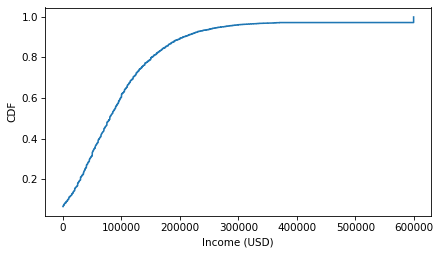

In [58]:
from empiricaldist import Cdf
cdf_income = Cdf.from_seq(nlsy["income"])
cdf_income.step()
decorate(xlabel="Income (USD)", ylabel="CDF")


In [65]:
valid = nlsy.dropna(subset=["piat_math", "income"])
piat_math_rank = valid["piat_math"].rank(method="first")
income_rank = valid["income"].rank(method="first")
piat_math_rank
income_rank

1       3550.0
2       1988.0
9       3998.0
10      2412.0
15      2558.0
         ...  
8972    2479.0
8973    3882.0
8977    1687.0
8980    1514.0
8983    1688.0
Name: income, Length: 4101, dtype: float64

In [62]:
income_rank.min(), income_rank.max()

(np.float64(1.0), np.float64(4101.0))

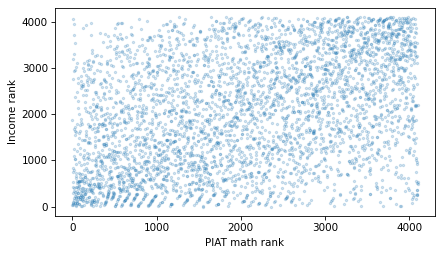

In [63]:
plt.scatter(piat_math_rank, income_rank, s=5, alpha=0.2)
decorate(xlabel="PIAT math rank", ylabel="Income rank")

In [66]:
np.corrcoef(piat_math_rank, income_rank)[0, 1]

np.float64(0.38148396696764847)